# Setup Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../../")
#from microfit import run_plotter as rp
#from microfit import histogram as hist
import math
from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

data_pot = 1.67e+20 # Run 1 bnb (numu) OG Test00

rundata = {
    'data': None,
    'ext': None,
    'mc': None,
    'nue': None,
    'drt': None
}

for key, df in rundata.items():
    if key != 'data':
        print(key)
        rundata[key] = pd.read_pickle(f'/exp/uboone/data/users/jbtyler1/PELEE/tmp_pickles/{key}.pkl')


ext
mc
nue
drt


In [2]:
df = rundata["mc"]

# Tests & Info

In [3]:
#type(df)

In [4]:
#df.columns

In [5]:
#'SubChrnkv_E' in df.columns

In [6]:
#df["SubChrnkv_E"]

In [7]:
#len(df)

In [8]:
#for key, df1 in rundata.items():
#    print(key)
#    if df1 is None:
#        print("None")
#    else:
#        print( 'SubChrnkv_E' in df1.columns )
#        print( 'true_KE_vector' in df1.columns )    
#        print( len(df1))

In [9]:
#for col in rundata['mc'].columns:
#    print(col)

#### true_e_visible
#### theta
#### nslice
#### nelec

#### nu_e (mc truth verified)

#### proton_e (proton energy of first highest momentum proton)

#### nproton (how many protons)

#### proton_range_energy
#### trk_energy_tot

#### neutrino_energy (effectively a reconstructed variable)
##### from data_loading line 1921: df["trk_energy_tot"] + get_elm_from_vec_idx(muon_energy_correction_v, muon_idx)

#### n_protons_tot
#### mc_E

In [10]:
#df

In [11]:
#df["SubChrnkv_E"]

In [12]:
#plt

# Plotting Code

In [13]:
#preselection = "None"
#selection = "oLEEtrue" #Choose either "oLEEtrue" or "oLEEreco"
#
#binning_def = ("SubChrnkv_E", 20, (0, 2), "KE Below Cherenkov Threshold (20 Bins) [GeV]")
#binning = hist.Binning.from_config(*binning_def[:4])
#print(binning_def)
#signal_generator = hist.RunHistGenerator(
#    rundata,
#    binning,
#    data_pot=data_pot,
#    selection=selection,
#    preselection=preselection,
#    sideband_generator=None,
#    uncertainty_defaults=None,
#)

In [14]:
#plotter = rp.RunHistPlotter(signal_generator)
#axes1 = plotter.plot(
#    category_column="mc_pdg", #Choose either "mc_pdg" (for truth vars) or "backtracked_pdg" (for reco vars)
#    include_multisim_errors=False,           #systematic errors
#    add_ext_error_floor=False,               #?
#    show_data_mc_ratio=False,                #ratio plot on bottom
#    show_chi_square=False,                   #statistical test useful for data & reco
#)

Text(0, 0.5, 'Count (Log-Scale)')

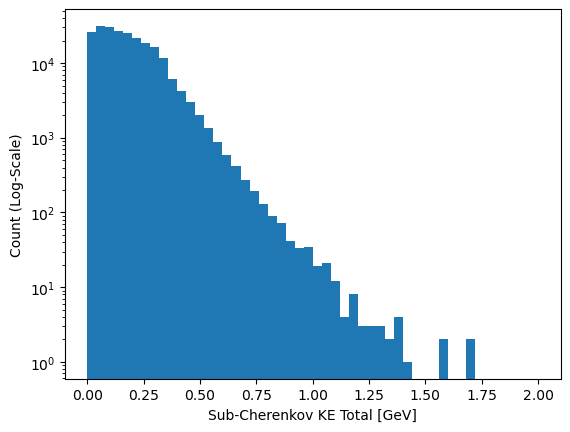

In [109]:
myhisto = plt.hist(df["SubChrnkv_E"], bins=50, range=(0.000000001,2), log=True)
plt.xlabel("Sub-Cherenkov KE Total [GeV]")
plt.ylabel("Count (Log-Scale)")

Text(0, 0.5, 'Count')

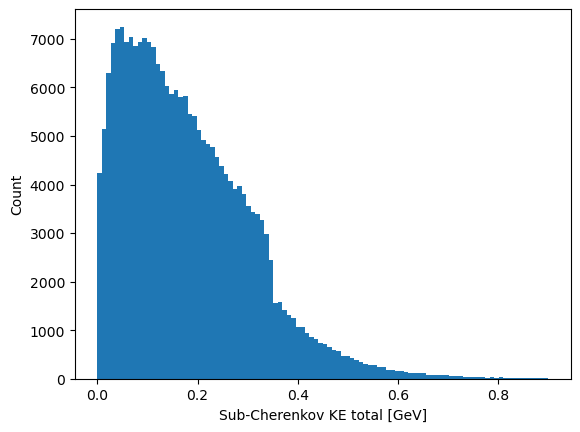

In [16]:
myhisto2 = plt.hist(df["SubChrnkv_E"], bins=100, range=(0.0000001,0.9), log=False)
plt.xlabel("Sub-Cherenkov KE total [GeV]")
plt.ylabel("Count")
#presentation

Text(0, 0.5, 'Count')

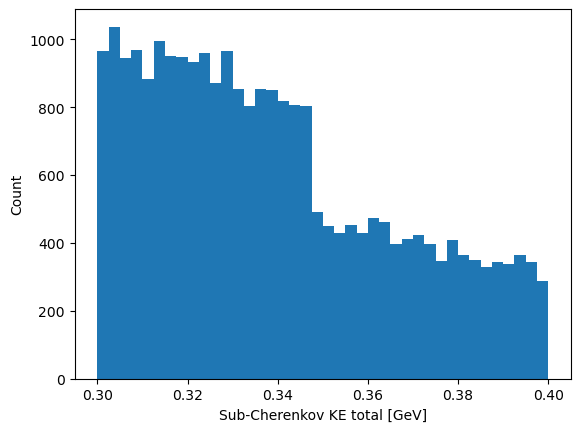

In [17]:
myhisto3 = plt.hist(df["SubChrnkv_E"], bins=40, range=(0.3,0.4), log=False)
plt.xlabel("Sub-Cherenkov KE total [GeV]")
plt.ylabel("Count")

Text(0, 0.5, 'Sub-Cherenkov KE total [GeV]')

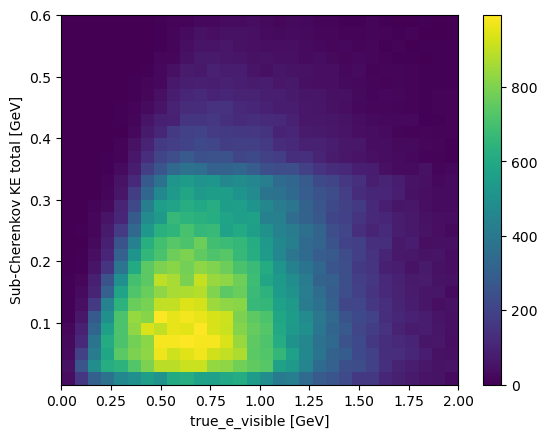

In [18]:
myhisto_2d1 = plt.hist2d(df["true_e_visible"], df["SubChrnkv_E"], bins=30, range=[[0,2.0],[0.00001,0.6]])
#(df["x"], df["y"], range=[[x1,x2],[y1,y2]])
plt.colorbar()
plt.xlabel("true_e_visible [GeV]")
plt.ylabel("Sub-Cherenkov KE total [GeV]")

Text(0, 0.5, 'Sub-Cherenkov KE total [GeV]')

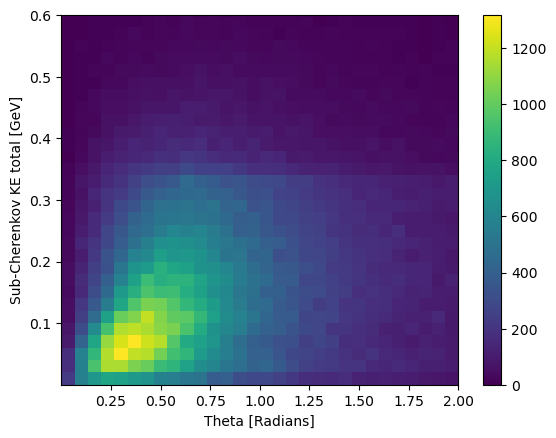

In [19]:
myhisto_2d2 = plt.hist2d(df["theta"], df["SubChrnkv_E"], bins=30, range=[[0.00001,2],[0.00001,0.6]])
plt.colorbar()
plt.xlabel("Theta [Radians]")
plt.ylabel("Sub-Cherenkov KE total [GeV]")

Text(0, 0.5, 'Sub-Cherenkov KE total [GeV]')

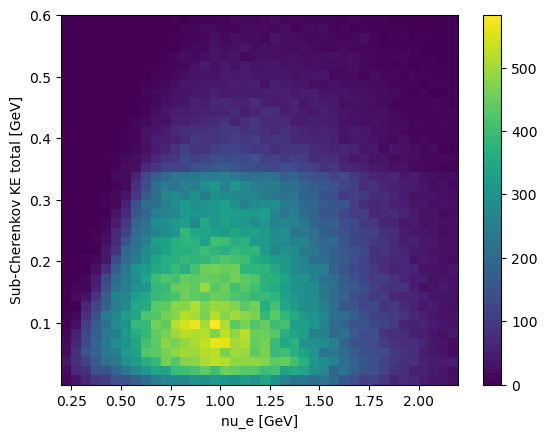

In [20]:
myhisto_2d3 = plt.hist2d(df["nu_e"], df["SubChrnkv_E"], bins=40, range=[[0.2,2.2],[0.00001,0.6]])
plt.colorbar()
plt.xlabel("nu_e [GeV]") #mc truth
plt.ylabel("Sub-Cherenkov KE total [GeV]")

In [21]:
#df["nu_e"]

In [22]:
#df["nu_e"] >= 1.0 

In [23]:
#(df["nu_e"] >= 1.0) & (df["nu_e"]  < 1.1)

In [24]:
#df["nu_e"][(df["nu_e"] >= 1.0) & (df["nu_e"]  < 1.1)]

Text(0, 0.5, 'Count')

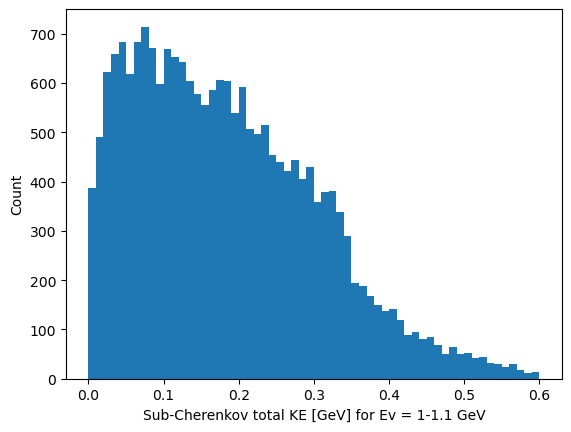

In [56]:
myhisto_1d3 = plt.hist(df["SubChrnkv_E"][(df["nu_e"] >= 1.0) & (df["nu_e"]  < 1.1)], bins=60, range=[0.0000001,0.6])
# Forces variable to be plotted only for second variable's parameters
# Looks approx same as full spectrum
plt.xlabel("Sub-Cherenkov total KE [GeV] for Ev = 1-1.1 GeV")
plt.ylabel("Count")
#Backup slide

Text(0, 0.5, 'Count')

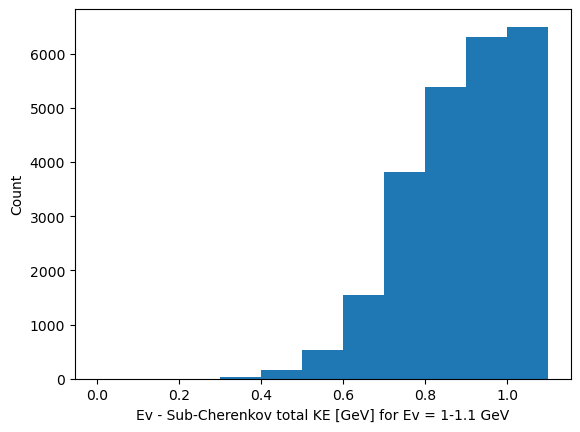

In [57]:
myhisto_1d3 = plt.hist(df["nu_e"] - df["SubChrnkv_E"][(df["nu_e"] >= 1.0) & (df["nu_e"]  < 1.1)], bins=11, range=[0,1.1])
plt.xlabel("Ev - Sub-Cherenkov total KE [GeV] for Ev = 1-1.1 GeV")
plt.ylabel("Count")
#presentation

In [27]:
#1.05 - df["SubChrnkv_E"][(df["nu_e"] >= 1.0) & (df["nu_e"]  < 1.1)]

Text(0.5, 0, 'Proton Energy [GeV]')

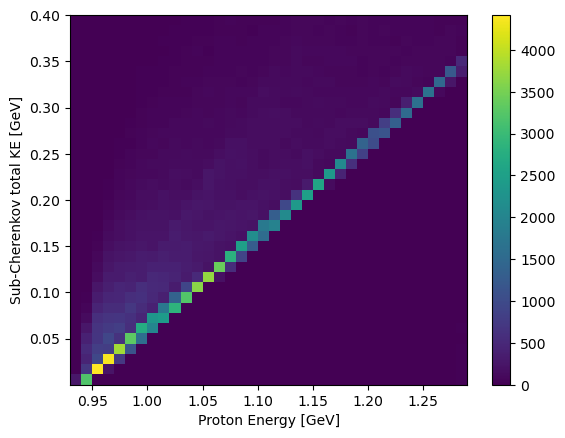

In [58]:
myhisto_2d4 = plt.hist2d(df["proton_e"], df["SubChrnkv_E"], bins=36, range=[[0.93,1.29],[0.00001,0.4]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Proton Energy [GeV]")

Text(0.5, 0, 'nslice')

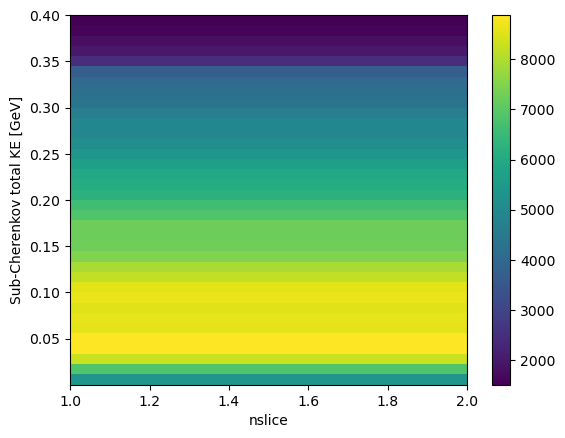

In [60]:
myhisto_2d5 = plt.hist2d(df["nslice"], df["SubChrnkv_E"], bins=[1,36], range=[[1,2],[0.00001,0.4]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("nslice")

In [30]:
#myhisto_1d4 = plt.hist(df["nslice"], bins=10)
#plt.colorbar()

Text(0.5, 0, 'Number of Protons')

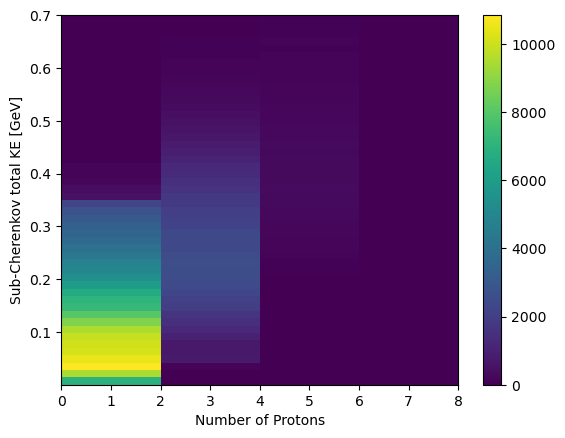

In [109]:
myhisto_2d6 = plt.hist2d(df["nproton"], df["SubChrnkv_E"], bins=[4,50], range=[[0,8],[0.00001,0.7]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Number of Protons")

Text(0.5, 0, 'Number of Protons')

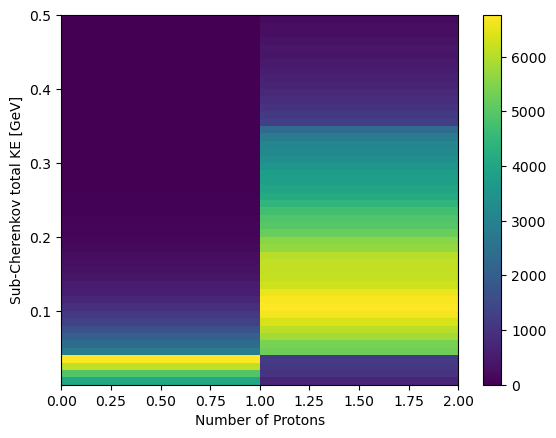

In [62]:
myhisto_2d6a = plt.hist2d(df["nproton"], df["SubChrnkv_E"], bins=[2,50], range=[[0,2],[0.00001,0.5]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Number of Protons")

Text(0.5, 0, 'Number of Protons')

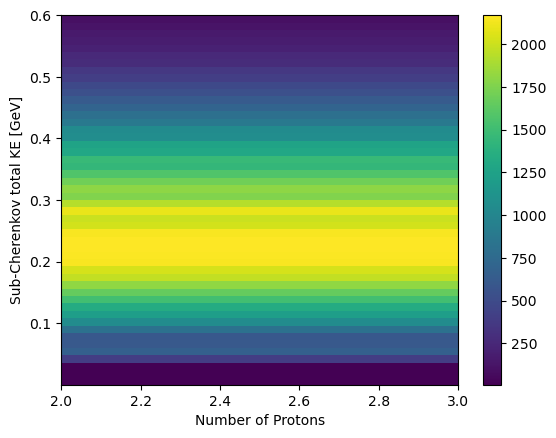

In [63]:
myhisto_2d6b = plt.hist2d(df["nproton"], df["SubChrnkv_E"], bins=[1,50], range=[[2,3],[0.00001,0.6]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Number of Protons")

Text(0.5, 0, 'Number of Protons')

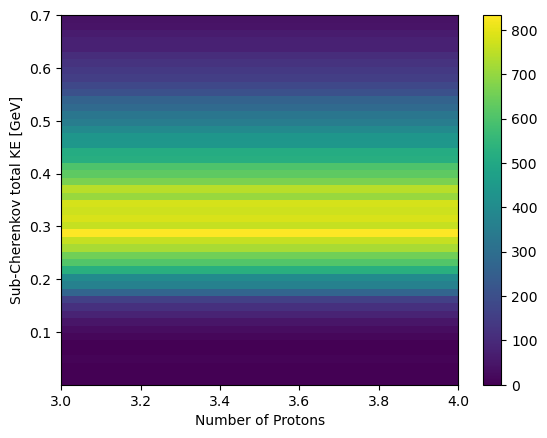

In [64]:
myhisto_2d6c = plt.hist2d(df["nproton"], df["SubChrnkv_E"], bins=[1,50], range=[[3,4],[0.00001,0.7]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Number of Protons")

Text(0, 0.5, 'Count')

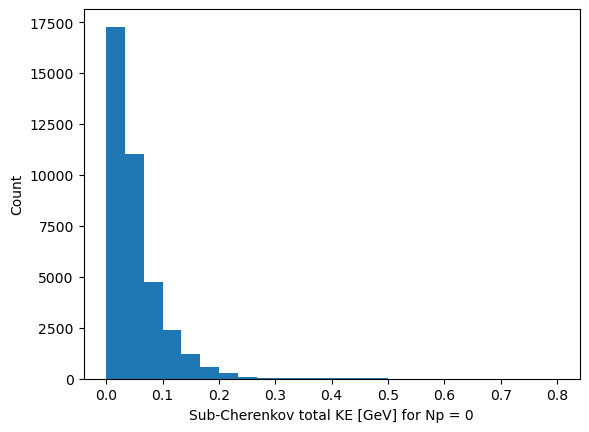

In [13]:
myhisto_1d3a = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 0.0) & (df["nproton"]  < 1.0)], 
                        bins=24, range=[0.000001,0.8], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 0")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

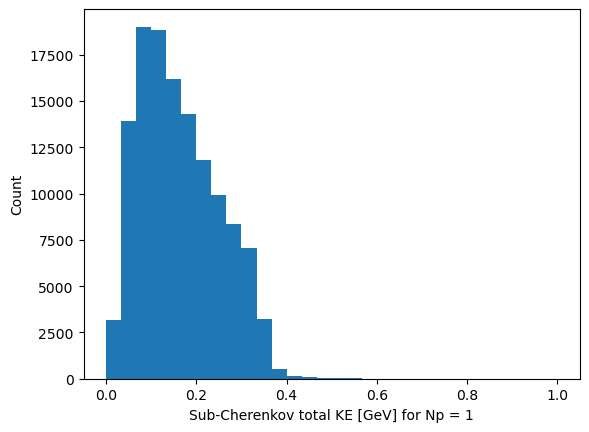

In [14]:
myhisto_1d3b = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 1.0) & (df["nproton"]  < 2.0)], 
                        bins=30, range=[0.000001,1.0], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 1")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

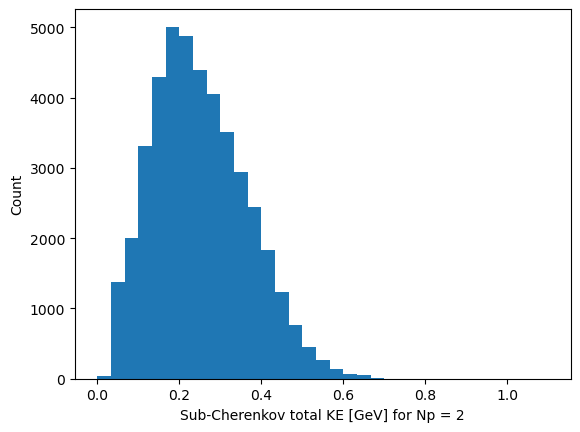

In [135]:
myhisto_1d3c = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 2.0) & (df["nproton"]  < 3.0)], 
                        bins=33, range=[0.000001,1.1], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 2")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

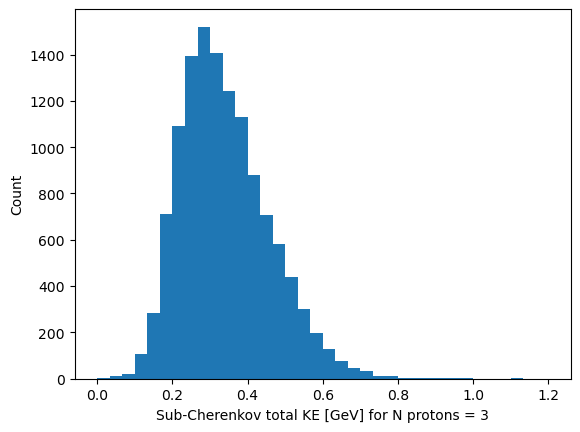

In [140]:
myhisto_1d3d = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 3.0) & (df["nproton"]  < 4.0)], 
                        bins=36, range=[0,1.2], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for N protons = 3")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

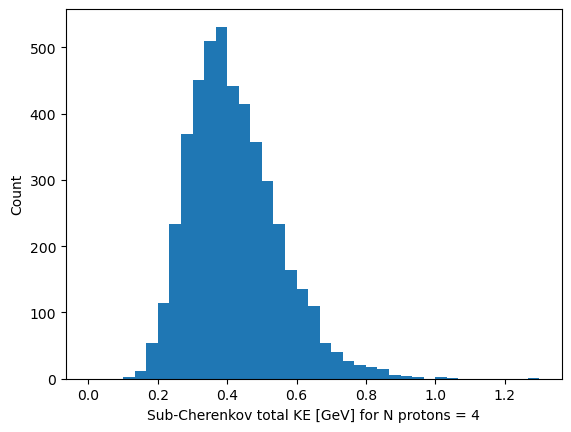

In [148]:
myhisto_1d3e = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 4.0) & (df["nproton"]  < 5.0)], 
                        bins=39, range=[0,1.3], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for N protons = 4")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

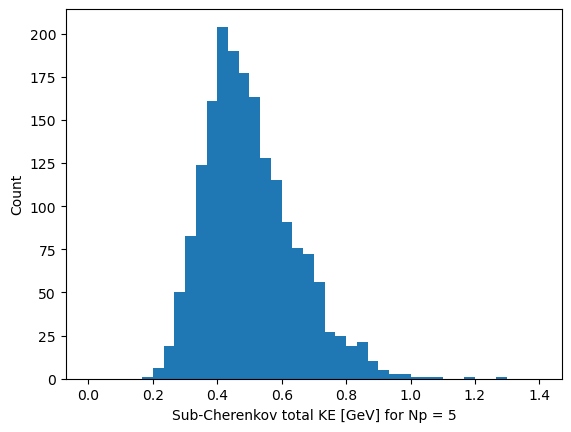

In [163]:
myhisto_1d3f = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0) & (df["nproton"] < 6.0)], 
                        bins=42, range=[0.000001,1.4], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 5")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

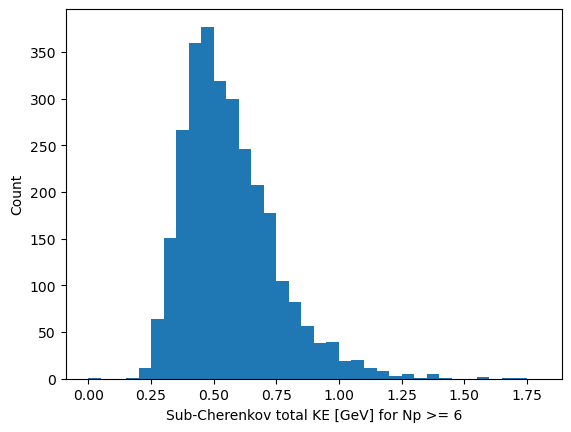

In [91]:
myhisto_1d3g = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0)], 
                        bins=36, range=[0,1.8], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np >= 6")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

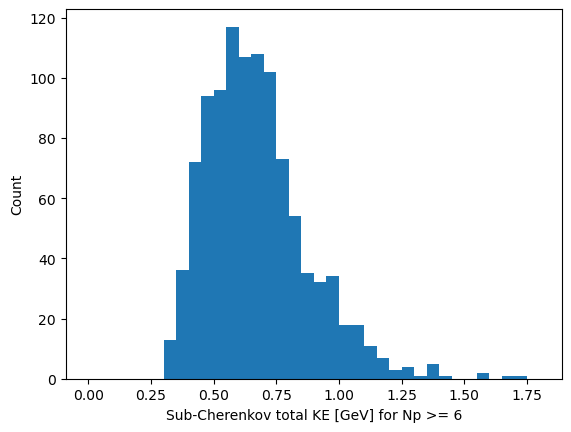

In [90]:
myhisto_1d3g = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 6.0)], 
                        bins=36, range=[0,1.8], log = False)
# Forces variable to be plotted only for second variable's parameters
plt.xlabel("Sub-Cherenkov total KE [GeV] for Np >= 6")
plt.ylabel("Count")

Text(0, 0.5, 'Count (log-scale)')

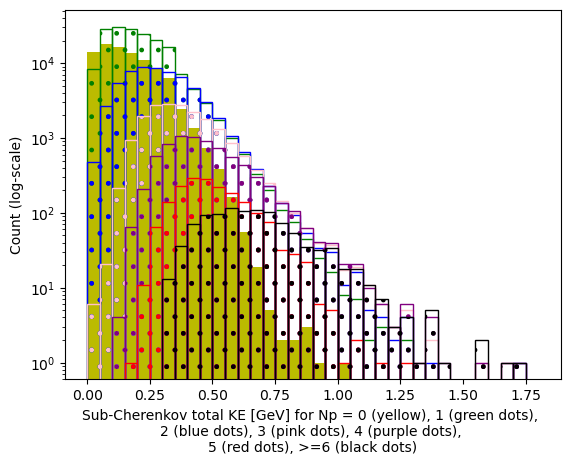

In [22]:
myhisto_1d3a = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 0.0) & (df["nu_e"] < 1.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#bbbb00')#, edgecolor='black')
myhisto_1d3b = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 1.0) & (df["nu_e"] < 2.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='green', hatch='.')
myhisto_1d3c = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 2.0) & (df["nu_e"] < 3.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='blue', hatch='.')
myhisto_1d3d = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 3.0) & (df["nu_e"] < 4.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='pink', hatch='.')
myhisto_1d3e = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 4.0) & (df["nu_e"] < 5.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='purple', hatch='.')
myhisto_1d3f = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0) & (df["nproton"] < 6.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='red', hatch='.')
myhisto_1d3g = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 6.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='none', edgecolor='black', hatch='.')

plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 0 (yellow), 1 (green dots), \n2 (blue dots), 3 (pink dots), 4 (purple dots), \n5 (red dots), >=6 (black dots)")
plt.ylabel("Count (log-scale)")

Text(0, 0.5, 'Count (log-scale)')

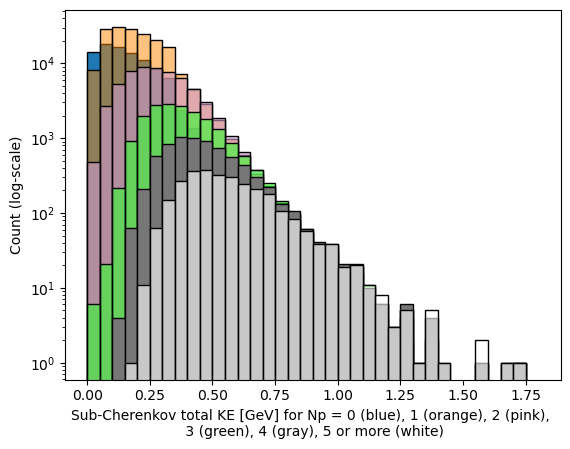

In [103]:
myhisto_1d3a = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 0.0) & (df["nu_e"] < 1.0)], bins=36, 
                        range=[0.000001,1.8], log = True, edgecolor='black')
myhisto_1d3b = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 1.0) & (df["nu_e"] < 2.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#ff880080', edgecolor='black')#, hatch='o')
myhisto_1d3c = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 2.0) & (df["nu_e"] < 3.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#cc99cc99', edgecolor='black')#, hatch='+')
myhisto_1d3d = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 3.0) & (df["nu_e"] < 4.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#33ff3399', edgecolor='black')#, hatch='*')
myhisto_1d3e = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 4.0) & (df["nu_e"] < 5.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#777777', edgecolor='black')#, hatch='/')
myhisto_1d3f2 = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0)], bins=36, 
                        range=[0.000001,1.8], log = True, facecolor='#ffffff99', edgecolor='black')#, hatch='|')

plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 0 (blue), 1 (orange), 2 (pink), \n 3 (green), 4 (gray), 5 or more (white)")
plt.ylabel("Count (log-scale)")

Text(0, 0.5, 'Count')

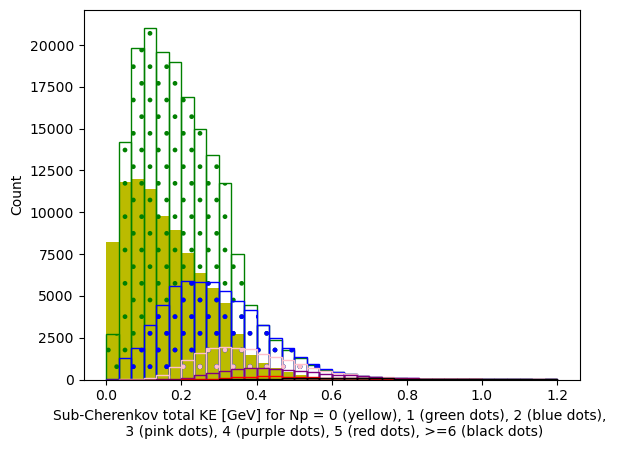

In [20]:
myhisto_1d3a = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 0.0) & (df["nu_e"] < 1.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#bbbb00')#, edgecolor='black')
myhisto_1d3b = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 1.0) & (df["nu_e"] < 2.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='green', hatch='.')
myhisto_1d3c = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 2.0) & (df["nu_e"] < 3.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='blue', hatch='.')
myhisto_1d3d = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 3.0) & (df["nu_e"] < 4.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='pink', hatch='.')
myhisto_1d3e = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 4.0) & (df["nu_e"] < 5.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='purple', hatch='.')
myhisto_1d3f = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0) & (df["nproton"] < 6.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='red', hatch='.')
myhisto_1d3g = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 6.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='none', edgecolor='black', hatch='.')

plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 0 (yellow), 1 (green dots), 2 (blue dots), \n 3 (pink dots), 4 (purple dots), 5 (red dots), >=6 (black dots)")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

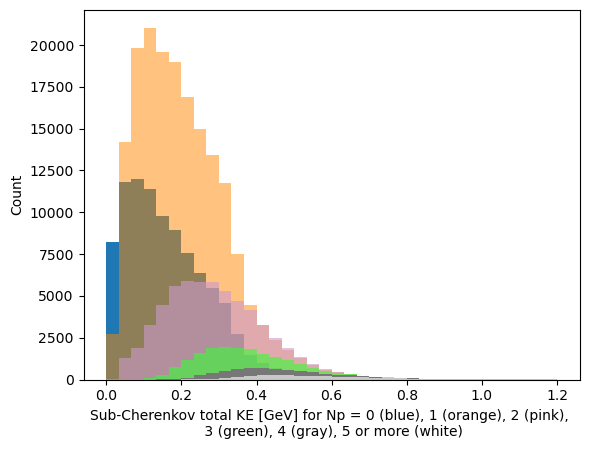

In [19]:
myhisto_1d3a = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 0.0) & (df["nu_e"] < 1.0)], bins=36, 
                        range=[0.000001,1.2], log = False)
myhisto_1d3b = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 1.0) & (df["nu_e"] < 2.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#ff880080')#, edgecolor='black', hatch='o')
myhisto_1d3c = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 2.0) & (df["nu_e"] < 3.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#cc99cc99')#, edgecolor='black', hatch='+')
myhisto_1d3d = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 3.0) & (df["nu_e"] < 4.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#33ff3399')#, edgecolor='black', hatch='*')
myhisto_1d3e = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 4.0) & (df["nu_e"] < 5.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#777777')#, edgecolor='black', hatch='/')
myhisto_1d3f2 = plt.hist(df["SubChrnkv_E"][(df["nproton"] >= 5.0)], bins=36, 
                        range=[0.000001,1.2], log = False, facecolor='#ffffff99')#, edgecolor='black', hatch='|')

plt.xlabel("Sub-Cherenkov total KE [GeV] for Np = 0 (blue), 1 (orange), 2 (pink), \n 3 (green), 4 (gray), 5 or more (white)")
plt.ylabel("Count")

Text(0.5, 0, 'proton_range_energy')

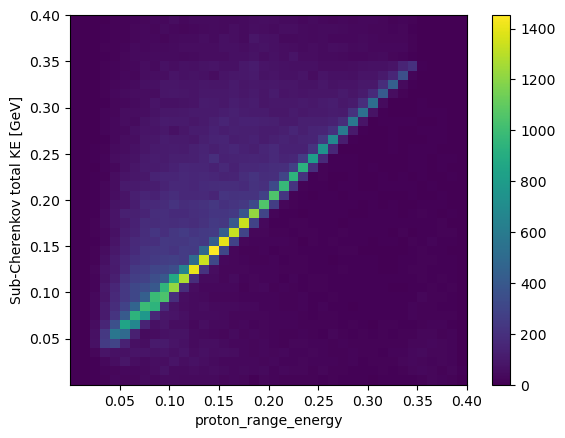

In [65]:
myhisto_2d7 = plt.hist2d(df["proton_range_energy"], df["SubChrnkv_E"], bins=[40,40], range=[[0.00001,0.4],[0.00001,0.4]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("proton_range_energy")

Text(0.5, 0, 'Total Track Energy [GeV]')

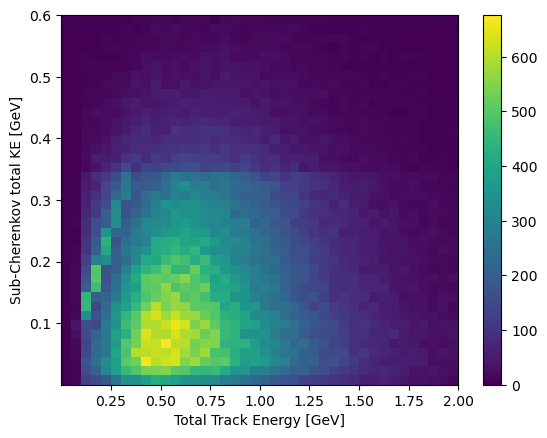

In [122]:
myhisto_2d8 = plt.hist2d(df["trk_energy_tot"], df["SubChrnkv_E"], bins=[40,40], range=[[0.00001,2],[0.00001,0.6]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Total Track Energy [GeV]")

Text(0.5, 0, 'Total Track Energy [GeV]')

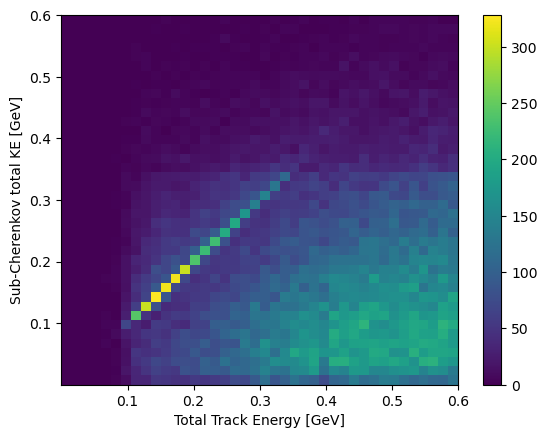

In [123]:
myhisto_2d8 = plt.hist2d(df["trk_energy_tot"], df["SubChrnkv_E"], bins=[40,40], range=[[0.00001,0.6],[0.00001,0.6]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Total Track Energy [GeV]")

Text(0.5, 0, 'Neutrino Energy [GeV]')

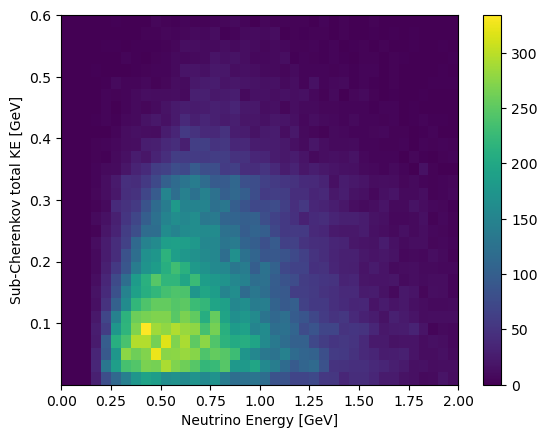

In [67]:
#
myhisto_2d9 = plt.hist2d(df["neutrino_energy"], df["SubChrnkv_E"], bins=[40,30], range=[[0,2],[0.00001,0.6]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Neutrino Energy [GeV]")

Text(0.5, 0, 'Neutrino Energy (nu_e) [GeV]')

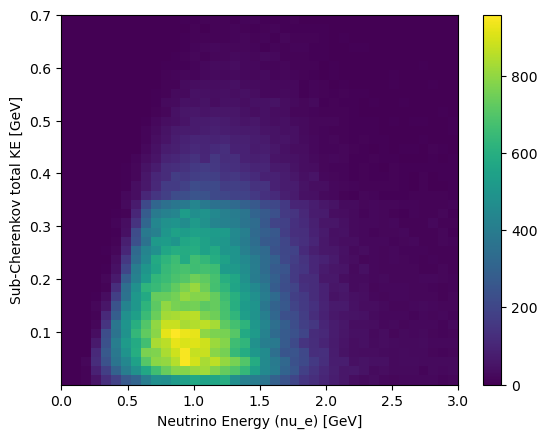

In [116]:
#
myhisto_2d9 = plt.hist2d(df["nu_e"], df["SubChrnkv_E"], bins=[40,40], range=[[0,3],[0.00001,0.7]])
plt.colorbar()
plt.ylabel("Sub-Cherenkov total KE [GeV]")
plt.xlabel("Neutrino Energy (nu_e) [GeV]")

Text(0, 0.5, 'Count')

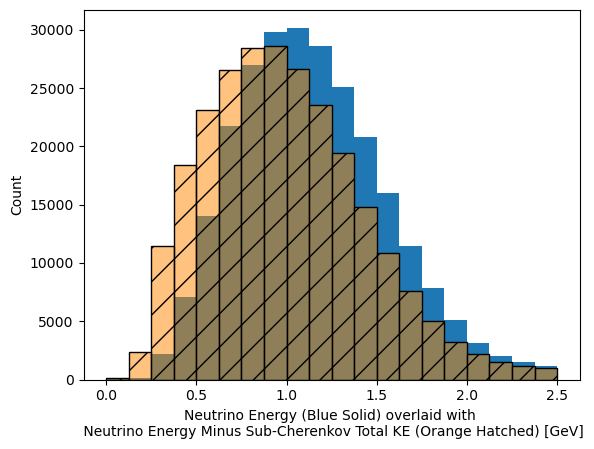

In [71]:
myhistox = plt.hist(df["nu_e"], bins=20, range=[0,2.5])
myhistoy = plt.hist(df["nu_e"]-df["SubChrnkv_E"], bins=20, range=[0,2.5], hatch='/', facecolor='#ff880080', edgecolor='black')
plt.xlabel("Neutrino Energy (Blue Solid) overlaid with \n Neutrino Energy Minus Sub-Cherenkov Total KE (Orange Hatched) [GeV]")
plt.ylabel("Count")
#Presentation

Text(0, 0.5, 'Count')

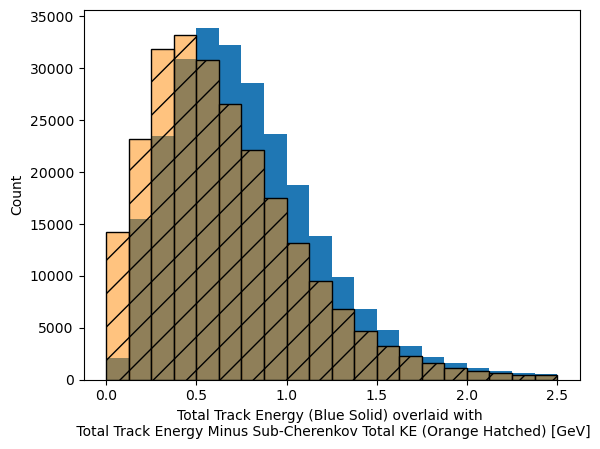

In [69]:
myhistox = plt.hist(df["trk_energy_tot"], bins=20, range=[0,2.5])
myhistoy = plt.hist(df["trk_energy_tot"]-df["SubChrnkv_E"], bins=20, range=[0,2.5], hatch='/', facecolor='#ff880080', edgecolor='black')
plt.xlabel("Total Track Energy (Blue Solid) overlaid with \n Total Track Energy Minus Sub-Cherenkov Total KE (Orange Hatched) [GeV]")
plt.ylabel("Count")
#presentation

In [40]:
#df["mc_E"]

In [41]:
#df["SubChrnkv_E"]

Text(0, 0.5, 'neutrino_energy (Reconstructed) [GeV]')

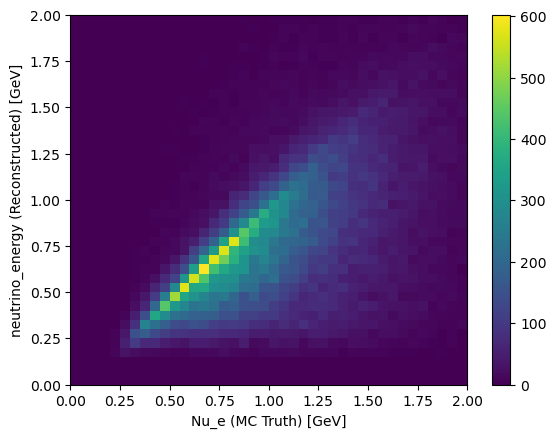

In [106]:
myhisto_2d = plt.hist2d(df["nu_e"], df["neutrino_energy"], bins=[40,40], range=[[0,2],[0,2]])
plt.colorbar()
plt.xlabel("Nu_e (MC Truth) [GeV]")
plt.ylabel("neutrino_energy (Reconstructed) [GeV]")
#nu_E -> monte carlo

Text(0, 0.5, 'Count')

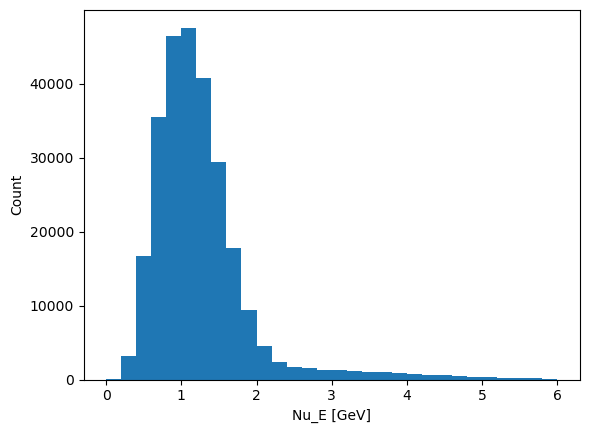

In [24]:
myhisto_1d20 = plt.hist(df["nu_e"], bins=30, range=[0,6], log = False)
plt.xlabel("Nu_E [GeV]")
plt.ylabel("Count")